In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/online_retail.csv"
)


#### Visualize customer and revenue distributions

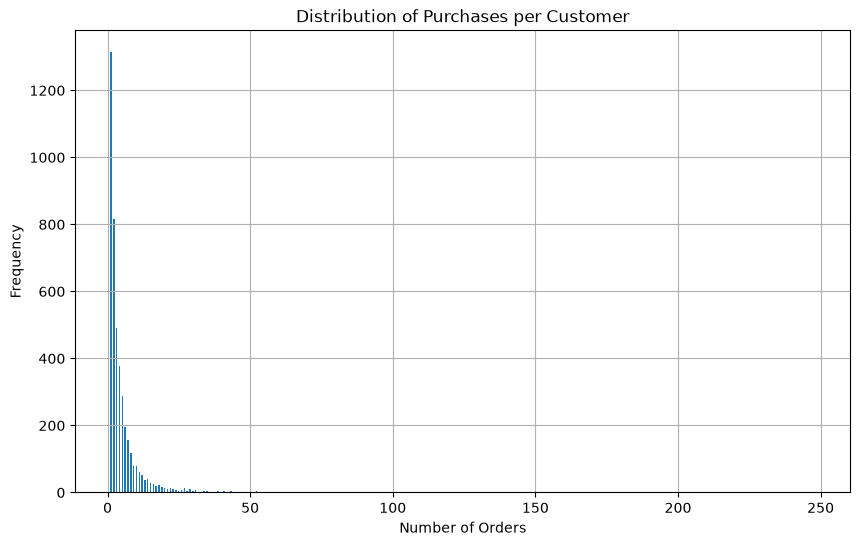

In [6]:
# graph distribution of purchases per customer

plt.figure(figsize=(10, 6))
df.groupby('CustomerID')['InvoiceNo'].nunique().hist(bins=500)
plt.xlabel('Number of Orders')      
plt.ylabel('Frequency')
plt.title('Distribution of Purchases per Customer')
plt.show()

there are a lot of customers that have only one purchase.
- what did they buy
- are they new
- are they a group of their own or are they in the same group as 2-5 purchases

In [7]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

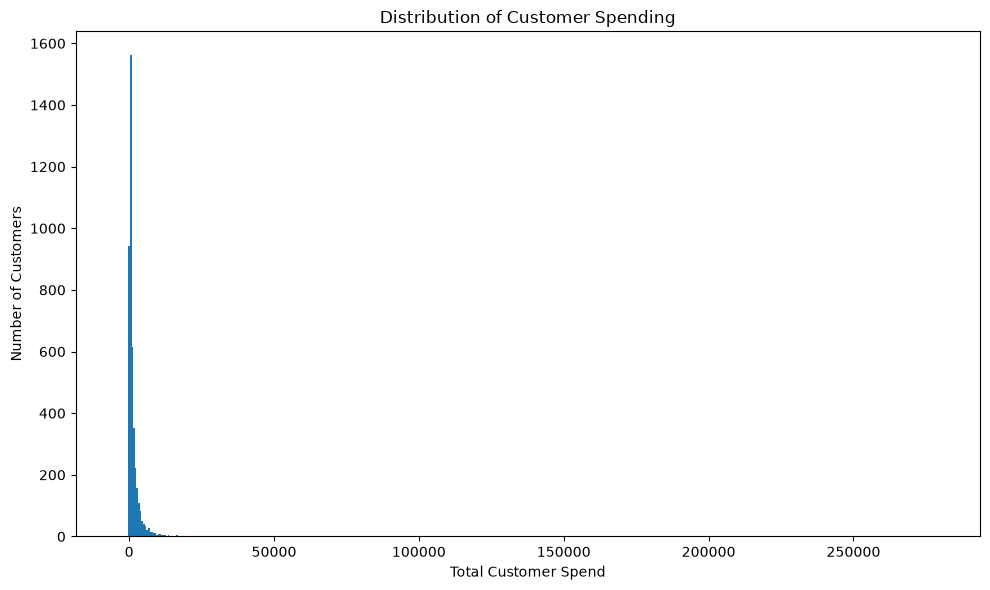

In [8]:
customer_spend = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.hist(
    customer_spend,
    bins=500
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

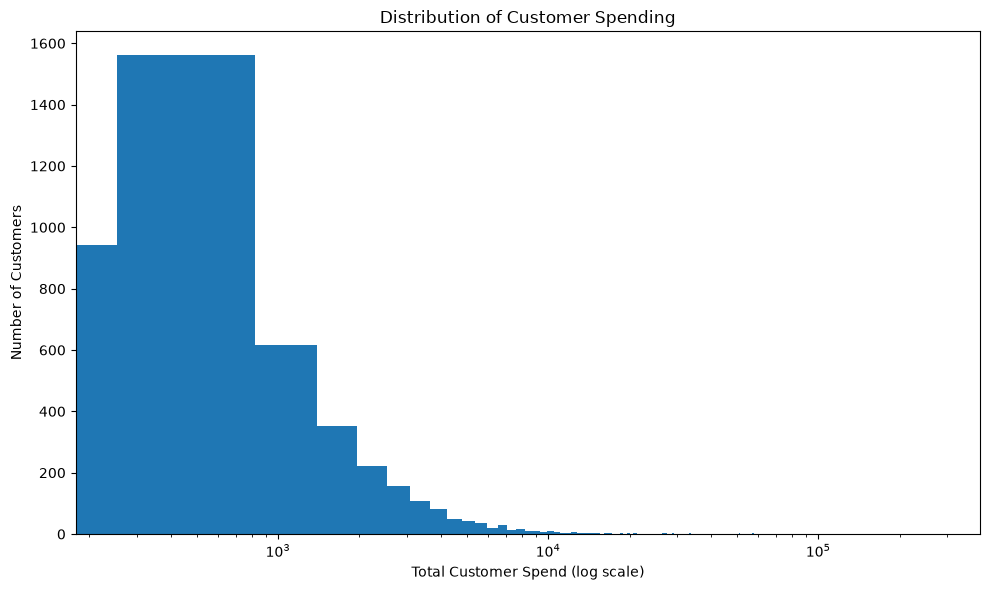

In [9]:
# retail spending is heavily skewed, using a log x-axis
plt.figure(figsize=(10, 6))

plt.hist(
    customer_spend,
    bins=500
)

plt.xscale("log")

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend (log scale)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

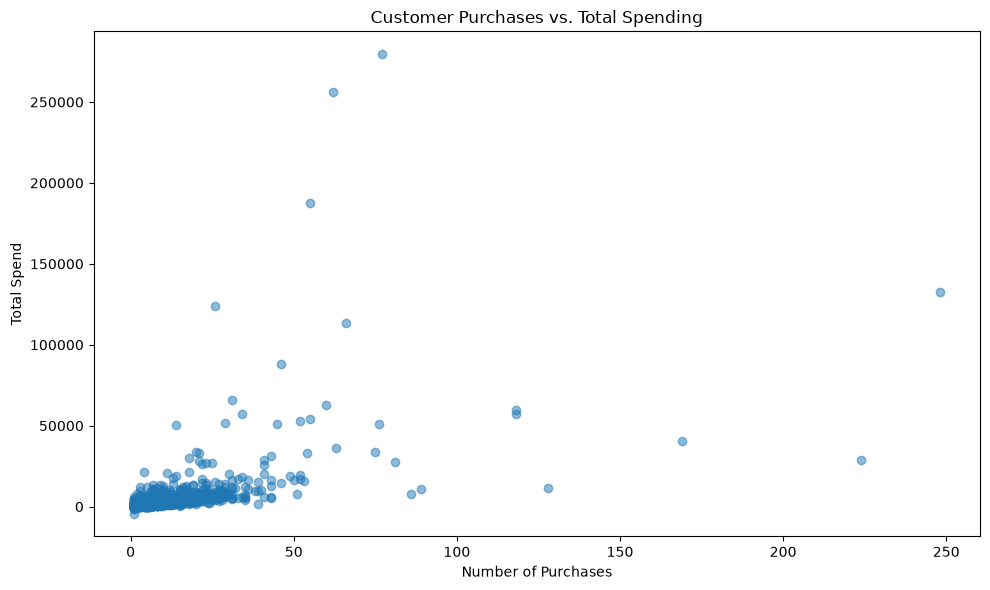

In [10]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum")
    )
)

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Purchases"],
    customer_summary["Total_Spend"],
    alpha=0.5
)

plt.title("Customer Purchases vs. Total Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spend")

plt.tight_layout()
plt.show()

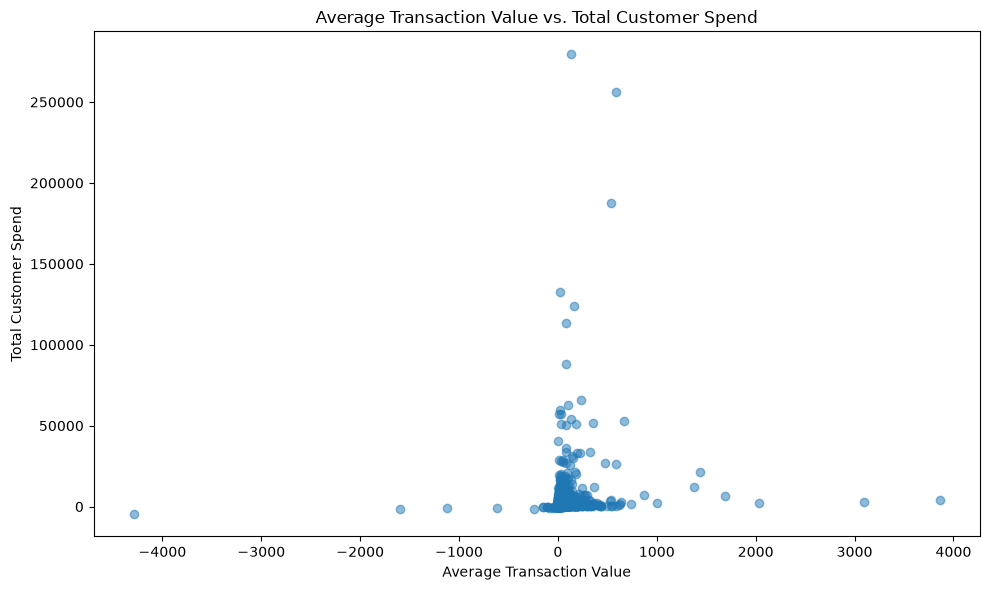

In [11]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean")
    )
)

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Avg_Transaction"],
    customer_summary["Total_Spend"],
    alpha=0.5
)

plt.title("Average Transaction Value vs. Total Customer Spend")
plt.xlabel("Average Transaction Value")
plt.ylabel("Total Customer Spend")

plt.tight_layout()
plt.show()

#### Looking for behavioral dimensions

In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

if not pd.api.types.is_string_dtype(df["CustomerID"]):
    df["CustomerID"] = df["CustomerID"].fillna(0).astype(int).astype(str)

/var/folders/53/vr8gs__x60sg207tybh25bv80000gn/T/ipykernel_44540/2789585944.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [13]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean")
    )
)

customer_summary.head(20)


,Purchases,Total_Spend,Avg_Transaction
CustomerID,,,
0,3710,1447682.12,10.717220
12346,2,0.00,0.000000
12347,7,4310.00,23.681319
12348,4,1797.24,57.975484
12349,1,1757.55,24.076027
12350,1,334.40,19.670588
12352,11,1545.41,16.267474
12353,1,89.00,22.250000
12354,1,1079.40,18.610345


#### Group with no customer ID

In [14]:
no_id = df[df["CustomerID"] == "0"].copy()

no_id[
    [
        "InvoiceNo",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "Country"
    ]
].head(2)

,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Revenue,Country
622,536414,2010-12-01 11:52:00,22139,NaN,56,0.00,0.00,United Kingdom
1443,536544,2010-12-01 14:32:00,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2.51,2.51,United Kingdom


In [15]:
no_id[
    ["Quantity", "UnitPrice", "Revenue"]
].describe()

,Quantity,UnitPrice,Revenue
count,135080.000000,135080.000000,135080.000000
mean,1.995573,8.076577,10.717220
std,66.696153,151.900816,157.967893
min,-9600.000000,-11062.060000,-17836.460000
25%,1.000000,1.630000,2.460000
50%,1.000000,3.290000,4.960000
75%,3.000000,5.450000,10.790000
max,5568.000000,17836.460000,13541.330000


In [16]:
no_id["Revenue"].sum()

np.float64(1447682.12)

In [17]:
no_id["InvoiceDate"].agg(["min", "max"])

min   2010-12-01 11:52:00
max   2011-12-09 10:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [18]:
no_ID_products = (
    no_id
    .groupby("Description")
    .agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

no_ID_products.head(20)

,Units,Revenue,Transactions
Description,,,
DOTCOM POSTAGE,691,194339.12,693
REGENCY CAKESTAND 3 TIER,1478,31891.79,285
PARTY BUNTING,2995,30615.45,307
PAPER CHAIN KIT 50'S CHRISTMAS,3738,22291.46,180
CHARLOTTE BAG SUKI DESIGN,9177,22139.30,297
HOT WATER BOTTLE TEA AND SYMPATHY,1964,17407.37,130
RABBIT NIGHT LIGHT,3586,15618.79,193
RED RETROSPOT CHARLOTTE BAG,4962,11650.94,295
POPCORN HOLDER,5830,10871.16,171


In [19]:
no_id["Month"] = no_id["InvoiceDate"].dt.to_period("M")

no_id_monthly = (
    no_id
    .groupby("Month")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

no_id_monthly

,Transactions,Units,Revenue
Month,,,
2010-12,317,45866,194353.00
2011-01,240,39587,84925.88
2011-02,191,15156,61516.50
2011-03,364,7860,103302.47
2011-04,360,10513,67159.27
2011-05,313,12539,75082.43
2011-06,305,-15299,83109.96
2011-07,334,27698,107061.63
2011-08,193,19587,66312.51


In [20]:

print("Earliest time:", no_id["InvoiceDate"].dt.time.min())
print("Latest time:", no_id["InvoiceDate"].dt.time.max())


Earliest time: 08:20:00
Latest time: 19:49:00


In [21]:
no_id["Hour"] = no_id["InvoiceDate"].dt.hour

hourly_volume = (
    no_id
    .groupby("Hour")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

hourly_volume

,Transactions,Units,Revenue
Hour,,,
8,16,853,1737.59
9,202,33357,111619.22
10,348,-2490,178499.56
11,395,8578,92799.01
12,365,8242,25392.52
13,326,11655,54830.94
14,492,33980,146609.08
15,664,66300,290499.42
16,461,66703,281749.93


In [22]:
no_id["Day"] = no_id["InvoiceDate"].dt.day_name()


day_volume = (
    no_id
    .groupby("Day")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)


In [23]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_volume = day_volume.reindex(day_order)

day_volume

,Transactions,Units,Revenue
Day,,,
Monday,626.0,73668.0,314057.92
Tuesday,830.0,49055.0,402989.20
Wednesday,705.0,28983.0,203669.52
Thursday,682.0,49941.0,206410.81
Friday,828.0,63397.0,299294.63
Saturday,NaN,NaN,NaN
Sunday,39.0,4518.0,21260.04


In [24]:
day_dates = (
    no_id
    .assign(Day=no_id["InvoiceDate"].dt.day_name())
    .groupby("Day")["InvoiceDate"]
    .apply(lambda x: x.dt.date.nunique())
    .reindex(day_order, fill_value=0)
)

day_dates

Day
Monday       47
Tuesday      52
Wednesday    53
Thursday     53
Friday       50
Saturday      0
Sunday       22
Name: InvoiceDate, dtype: int64

In [25]:
day_volume["Transaction_Pct"] = (
    day_volume["Transactions"] /
    day_volume["Transactions"].sum() * 100
)

day_volume

,Transactions,Units,Revenue,Transaction_Pct
Day,,,,
Monday,626.0,73668.0,314057.92,16.873315
Tuesday,830.0,49055.0,402989.20,22.371968
Wednesday,705.0,28983.0,203669.52,19.002695
Thursday,682.0,49941.0,206410.81,18.382749
Friday,828.0,63397.0,299294.63,22.318059
Saturday,NaN,NaN,NaN,NaN
Sunday,39.0,4518.0,21260.04,1.051213


The no_id transactions appear to represent a distinct group within the dataset and may represent direct or end-user sales rather than purchases from identified reseller customers. This is a working hypothesis based on the purchasing patterns in the data, not something the dataset specifically identifies.

The no_id transactions occur mostly during the workweek, with sales recorded Monday through Friday and a smaller number on Sundays. Tuesday and Friday have the highest transaction volumes, but there isn't one day that stands out as dramatically busier than the others.

This is interesting because if these sales were primarily coming from something like a farmers market, makers market, pop-up event, or another periodic retail operation, I would expect to see much larger spikes on particular days. That pattern isn't really present in the data. Instead, the sales are spread across a number of weekdays, which makes a regular event-based sales channel less obvious.

The next step is to compare no_id and identified customers by revenue, units sold, product mix, transaction size, and timing. That should help determine whether these two groups are actually behaving like different types of sales channels.

#### Looking into the customers with ID 

In [26]:
identified = df[df["CustomerID"] != "0"].copy()

customer_summary = (
    identified
    .groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean"),
        Unique_Products=("StockCode", "nunique"),
    )
)

# (identified["CustomerID"] == 0).sum()
(customer_summary.index == "0").sum()

np.int64(0)

In [27]:
customer_purchases = (
    identified
    .groupby(["CustomerID", "InvoiceNo"])["InvoiceDate"]
    .min()
    .reset_index()
    .sort_values(["CustomerID", "InvoiceDate"])
)
customer_purchases["Days_Between"] = (
    customer_purchases
    .groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    .div(86400)
)
# (customer_purchases["CustomerID"] == "0").sum()
(customer_purchases["CustomerID"] == 0).sum()

np.int64(0)

In [28]:
purchase_timing = (
    customer_purchases
    .groupby("CustomerID")
    .agg(
        Avg_Days_Between=("Days_Between", "mean"),
        Variation_Days_Between=("Days_Between", "std")
    )
)
customer_summary = customer_summary.join(purchase_timing)



In [29]:
customer_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,4372.0,5.075480,9.338754,1.00,1.000000,3.000000,5.000000,248.000000
Total_Spend,4372.0,1898.459701,8219.345141,-4287.63,293.362500,648.075000,1611.725000,279489.020000
Avg_Transaction,4372.0,28.839013,127.323926,-4287.63,10.985960,16.918616,23.542941,3861.000000
Unique_Products,4372.0,61.211116,85.425119,1.00,15.000000,35.000000,77.000000,1794.000000
Avg_Days_Between,3059.0,60.637396,61.765206,0.00,21.109549,41.555417,76.036285,365.981944
Variation_Days_Between,2242.0,43.416895,37.675545,0.00,18.085442,32.615079,55.970387,253.249312


In [30]:
customer_summary[
    [
        "Purchases",
        "Avg_Days_Between",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,4372.0,5.075480,9.338754,1.00,1.000000,3.000000,5.000000,248.000000
Avg_Days_Between,3059.0,60.637396,61.765206,0.00,21.109549,41.555417,76.036285,365.981944
Total_Spend,4372.0,1898.459701,8219.345141,-4287.63,293.362500,648.075000,1611.725000,279489.020000
Avg_Transaction,4372.0,28.839013,127.323926,-4287.63,10.985960,16.918616,23.542941,3861.000000
Unique_Products,4372.0,61.211116,85.425119,1.00,15.000000,35.000000,77.000000,1794.000000
Variation_Days_Between,2242.0,43.416895,37.675545,0.00,18.085442,32.615079,55.970387,253.249312


In [31]:
customer_summary[

    [
        "Purchases",
        "Total_Spend",
        "Unique_Products"
    ]
].quantile([0.90, 0.95, 0.99])

,Purchases,Total_Spend,Unique_Products
0.90,11.0,3505.6000,142.00
0.95,16.0,5625.0040,202.35
0.99,36.0,17226.2949,354.00


#### Look into "corporate level buying

In [32]:
corporate_candidates = customer_summary[
    (
        (customer_summary["Purchases"] >= 16).astype(int)
        + (customer_summary["Total_Spend"] >= 5625.004).astype(int)
        + (customer_summary["Unique_Products"] >= 202.35).astype(int)
    ) >= 2
].copy()


In [33]:
len(corporate_candidates)

195

In [34]:
"0" in customer_summary.index

False

In [35]:
len(corporate_candidates) / len(customer_summary) * 100

4.460201280878317

In [36]:
corporate_candidates[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Avg_Days_Between",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,195.0,31.866667,30.019112,6.000000,18.000000,24.000000,34.000000,248.000000
Total_Spend,195.0,18866.686410,34254.550841,1296.440000,6325.760000,8574.110000,15417.560000,279489.020000
Avg_Transaction,195.0,55.037644,99.656348,2.771005,13.605313,23.034478,50.159282,667.732152
Unique_Products,195.0,253.953846,239.648460,9.000000,115.000000,226.000000,297.000000,1794.000000
Avg_Days_Between,195.0,16.527045,10.705486,1.506379,10.036210,14.531472,19.495154,64.788611
Variation_Days_Between,195.0,16.284527,11.618986,2.111138,9.527646,13.629063,18.524457,105.804256


In [37]:
other_customers = customer_summary[
    ~customer_summary.index.isin(corporate_candidates.index)
].copy()

In [38]:
comparison = pd.DataFrame({
    "High_Volume": corporate_candidates[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median(),
    "Other_Customers": other_customers[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median()
})

comparison

,High_Volume,Other_Customers
Purchases,24.000000,2.000000
Total_Spend,8574.110000,609.850000
Avg_Transaction,23.034478,16.796250
Unique_Products,226.000000,33.000000
Avg_Days_Between,14.531472,44.722321
Variation_Days_Between,13.629063,35.328823


High-volume customers showed substantially more frequent and diverse purchasing behavior than other customers. The median high-volume customer made 24 purchases compared with 2 for other customers and spent $8,574 compared with $610. They also purchased a much wider range of products, with 226 unique products compared with 33. Their average time between purchases was considerably shorter at 14.5 days versus 44.7 days, while the lower variation in purchase intervals (13.6 days versus 35.3 days) suggests their purchasing was also more consistent. Average transaction value was only moderately higher ($23.03 versus $16.80), indicating that the difference in customer value was driven primarily by how frequently and broadly customers purchased rather than by substantially larger individual transactions.

#### Testing the 20/80 rule

In [39]:
customer_count = len(customer_summary)

top_20_count = round(customer_count * 0.20)

top_20_customers = (
    customer_summary
    .sort_values("Total_Spend", ascending=False)
    .head(top_20_count)
    .copy()
)

len(top_20_customers)

874

In [40]:
other_80_customers = (
    customer_summary
    .drop(top_20_customers.index)
    .copy()
)

len(other_80_customers)

3498

In [41]:
comparison_80_20 = pd.DataFrame({
    "Top 20%": top_20_customers[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median(),

    "Other 80%": other_80_customers[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median()
})

comparison_80_20

,Top 20%,Other 80%
Purchases,10.000000,2.000000
Total_Spend,3511.110000,465.435000
Avg_Transaction,20.473382,16.219982
Unique_Products,115.000000,27.000000
Avg_Days_Between,28.458256,52.030870
Variation_Days_Between,24.582891,40.587918


In [42]:
top_20_revenue = top_20_customers["Total_Spend"].sum()
other_80_revenue = other_80_customers["Total_Spend"].sum()
total_revenue = customer_summary["Total_Spend"].sum()

top_20_revenue_share = top_20_revenue / total_revenue * 100
other_80_revenue_share = other_80_revenue / total_revenue * 100

top_20_revenue_share

np.float64(73.82295006221261)

In [43]:
pd.DataFrame({
    "Customers": [
        len(top_20_customers),
        len(other_80_customers)
    ],
    "Revenue": [
        top_20_revenue,
        other_80_revenue
    ],
    "Revenue_Share": [
        top_20_revenue_share,
        other_80_revenue_share
    ]
}, index=["Top 20%", "Other 80%"])

,Customers,Revenue,Revenue_Share
Top 20%,874,6127353.441,73.82295
Other 80%,3498,2172712.373,26.17705


In [44]:
top_20_customers.sort_values(
    "Total_Spend",
    ascending=False
)

,Purchases,Total_Spend,Avg_Transaction,Unique_Products,Avg_Days_Between,Variation_Days_Between
CustomerID,,,,,,
14646,77,279489.02,134.047492,703,4.645861,6.899815
18102,62,256438.49,592.236697,151,6.013069,10.990003
17450,55,187482.17,534.137236,127,6.651312,9.495838
14911,248,132572.62,22.458516,1794,1.506379,2.249975
12415,26,123725.45,159.030141,444,12.525278,13.285423
...,...,...,...,...,...,...
15531,2,2007.44,8.804561,196,22.038889,NaN
15372,1,2007.40,74.348148,27,NaN,NaN
16098,7,2005.63,29.934776,34,47.668287,19.015253


In [45]:
top_20_customers[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Avg_Days_Between",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,874.0,14.233410,17.596677,1.000000,6.000000,10.000000,16.000000,248.000000
Total_Spend,874.0,7010.701878,17450.666576,2003.850000,2581.407500,3511.110000,5632.720000,279489.020000
Avg_Transaction,874.0,55.899382,211.523308,2.771005,15.733061,20.473382,31.889757,3861.000000
Unique_Products,874.0,147.799771,143.818534,1.000000,72.000000,115.000000,184.750000,1794.000000
Avg_Days_Between,861.0,35.124446,29.145619,0.001042,17.501736,28.458256,43.190162,337.094444
Variation_Days_Between,845.0,30.030241,23.001238,0.000491,15.161210,24.582891,37.753389,190.014323


In [46]:
other_80_customers[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Avg_Days_Between",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,3498.0,2.787307,2.347539,1.00,1.000000,2.000000,4.000000,39.000000
Total_Spend,3498.0,621.129895,505.668262,-4287.63,234.405000,465.435000,909.170000,2002.400000
Avg_Transaction,3498.0,22.077789,94.153032,-4287.63,9.805893,16.219982,21.586801,1001.200000
Unique_Products,3498.0,39.576329,40.195548,1.00,13.000000,27.000000,53.000000,421.000000
Avg_Days_Between,2198.0,70.631322,67.988793,0.00,24.838433,52.030870,91.692650,365.981944
Variation_Days_Between,1397.0,51.514047,42.245676,0.00,21.852517,40.587918,69.953079,253.249312


The top 20% of customers generated approximately 73% of total revenue, indicating a strong concentration of revenue among a relatively small group of customers. While the distribution does not follow the 80/20 rule exactly, the pattern is close enough to support treating high-value customers as a distinct group for further analysis and potential follow-up automation.

#### limited products purchased

In [47]:
limited_product_customers = (
    customer_summary[
        customer_summary["Purchases"] > 1
    ]
    .sort_values("Unique_Products")
    [["Purchases", "Total_Spend", "Unique_Products"]]
)

limited_product_customers.head(20)

,Purchases,Total_Spend,Unique_Products
CustomerID,,,
12346,2,0.00,1
13147,4,712.80,1
13106,2,59.50,1
13068,2,344.00,1
15802,3,-451.42,1
17747,2,64.65,1
14682,2,52.00,1
17616,3,571.20,1
16308,4,2560.00,1


In [48]:
limited_product_customers = (
    customer_summary[
        customer_summary["Purchases"] > 1
    ]
    .sort_values("Unique_Products")
    [["Purchases", "Total_Spend", "Unique_Products"]]
)

limited_ids = limited_product_customers.head(20).index

limited_customer_products = (
    identified[
        identified["CustomerID"].isin(limited_ids)
    ]
    .groupby(
        ["CustomerID", "StockCode", "Description"],
        dropna=False
    )
    .agg(
        
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values(
        ["CustomerID", "Purchases", "Revenue"],
        ascending=[True, False, False]
    )
)

limited_customer_products

,CustomerID,StockCode,Description,Purchases,Units,Revenue
0,12346,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,0,0.00
1,12823,48138,DOORMAT UNION FLAG,5,230,1759.50
2,12875,17096,ASSORTED LAQUERED INCENSE HOLDERS,2,2019,343.23
3,13068,85099C,JUMBO BAG BAROQUE BLACK WHITE,2,200,344.00
4,13106,22456,NATURAL SLATE CHALKBOARD LARGE,2,14,59.50
5,13147,79321,CHILLI LIGHTS,4,144,712.80
6,13452,22656,VINTAGE BLUE KITCHEN CABINET,2,2,590.00
7,14682,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,2,80,52.00
8,15100,21258,VICTORIAN SEWING BOX LARGE,6,58,635.10
9,15649,79321,CHILLI LIGHTS,2,192,816.00


In [49]:
customer_category_spend = (
    identified
    .groupby(["CustomerID", "StockCode", "Description"])["Revenue"]
    .sum()
    .reset_index()
)

customer_category_spend["Category_Share"] = (
    customer_category_spend["Revenue"]*100
    / customer_category_spend.groupby("CustomerID")["Revenue"].transform("sum")
)

customer_category_spend = customer_category_spend.sort_values(
    ["CustomerID", "Category_Share"],
    ascending=[True, False]
)

customer_category_spend.head(20)

,CustomerID,StockCode,Description,Revenue,Category_Share
0,12346,23166,MEDIUM CERAMIC TOP STORAGE JAR,0.00,NaN
89,12347,84558A,3D DOG PICTURE PLAYING CARDS,371.70,8.624130
59,12347,23076,ICE CREAM SUNDAE LIP GLOSS,249.60,5.791183
34,12347,22423,REGENCY CAKESTAND 3 TIER,191.25,4.437355
60,12347,23084,RABBIT NIGHT LIGHT,153.84,3.569374
47,12347,22727,ALARM CLOCK BAKELIKE RED,135.00,3.132251
27,12347,22371,AIRLINE BAG VINTAGE TOKYO 78,132.40,3.071926
30,12347,22375,AIRLINE BAG VINTAGE JET SET BROWN,119.00,2.761021
16,12347,21731,RED TOADSTOOL LED NIGHT LIGHT,118.80,2.756381
74,12347,23316,RED REFECTORY CLOCK,97.80,2.269142


In [50]:
products = ["84558A", "23076", "22423", "23084"]

customer_12347_products = (
    identified[
        (identified["CustomerID"] == "12347") &
        (identified["StockCode"].isin(products))
    ]
    .groupby(["StockCode", "Description"])
    .agg(
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max"),
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("First_Purchase")
)

# customer_12347_products

In [51]:
#### Looking into the 80%

In [52]:
other_80_customers["Purchases"].describe()

count    3498.000000
mean        2.787307
std         2.347539
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        39.000000
Name: Purchases, dtype: float64

In [53]:
other_80_customers["Purchases"].value_counts().sort_index()

Purchases
1     1300
2      801
3      458
4      333
5      222
6      130
7       97
8       55
9       37
10      24
11      14
12       8
13       7
14       3
15       4
16       1
18       1
20       1
24       1
39       1
Name: count, dtype: int64

In [54]:
one_purchase_only = other_80_customers[
    other_80_customers["Purchases"] == 1
].copy()

multiple_purchases = other_80_customers[
    other_80_customers["Purchases"] > 1
].copy()

print("One purchase only:", len(one_purchase_only))
print("Multiple purchases:", len(multiple_purchases))

One purchase only: 1300
Multiple purchases: 2198


In [55]:
revenue_comparison = pd.DataFrame({
    "Other 80%": other_80_customers[
        other_80_customers["Total_Spend"] > 0.01
    ]["Total_Spend"].describe(),

    "Multiple Purchases": multiple_purchases[
        multiple_purchases["Total_Spend"] > 0.01
    ]["Total_Spend"].describe(),

    "One Purchase": one_purchase_only[
        one_purchase_only["Total_Spend"] > 0.01
    ]["Total_Spend"].describe()
}).round(2)

revenue_comparison

,Other 80%,Multiple Purchases,One Purchase
count,3443.00,2174.00,1269.00
mean,634.89,821.24,315.65
std,490.87,495.01,269.46
min,2.90,2.90,3.75
25%,245.88,410.89,147.59
50%,479.35,707.38,238.25
75%,915.12,1158.29,383.95
max,2002.40,2000.86,2002.40


Revenue was substantially higher among repeat customers than one-time customers. The median revenue for multiple-purchase customers was $707.38, compared with $238.25 for one-time customers, while the mean was $821.24 versus $315.65. The similar maximum values suggest that the difference is primarily driven by the overall purchasing behavior of repeat customers rather than a few exceptionally high-revenue customers. Overall, the results indicate that repeat purchasing is associated with significantly greater customer revenue within the other 80% group.


In [56]:
revenue_percentiles = pd.DataFrame({
    "Other 80%": other_80_customers[
        other_80_customers["Total_Spend"] > 0.01
    ]["Total_Spend"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),

    "Multiple Purchases": multiple_purchases[
        multiple_purchases["Total_Spend"] > 0.01
    ]["Total_Spend"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),

    "One Purchase": one_purchase_only[
        one_purchase_only["Total_Spend"] > 0.01
    ]["Total_Spend"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
}).round(2)

revenue_percentiles

,Other 80%,Multiple Purchases,One Purchase
0.25,245.88,410.89,147.59
0.50,479.35,707.38,238.25
0.75,915.12,1158.29,383.95
0.90,1421.56,1596.42,605.79
0.95,1682.33,1782.17,816.90
0.99,1918.67,1945.19,1534.98


Revenue is consistently higher among multiple-purchase customers across nearly every percentile. The median revenue is $707.38 for repeat customers compared with $238.25 for one-time customers, and the gap remains substantial through the 90th percentile. At the 99th percentile, however, the difference narrows considerably, with one-time customers reaching $1,534.98 compared with $1,945.19 for repeat customers. This suggests that while repeat customers generally generate more revenue, a small number of one-time customers can still generate relatively high revenue from a single purchase.

In [57]:
nov_dec_one_time = one_purchase_only[
    one_purchase_only.index.isin(
        identified[
            (identified["InvoiceDate"].dt.year == 2011) &
            (identified["InvoiceDate"].dt.month.isin([11, 12]))
        ]["CustomerID"].unique()
    )
]

len(nov_dec_one_time)

248

In [58]:
one_time_one_product = (
    identified[
        identified["CustomerID"].isin(one_purchase_only.index)
    ]
    .groupby(["CustomerID", "StockCode", "Description"], dropna=False)
    .agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

In [59]:
product_counts = (
    one_time_one_product
    .groupby("CustomerID")["StockCode"]
    .nunique()
)

one_product_customers = product_counts[
    product_counts == 1
].index

one_time_one_product = one_time_one_product[
    one_time_one_product["CustomerID"].isin(one_product_customers)
]

# one_time_one_product

In [60]:
one_purchase_dates = (
    identified[
        identified["CustomerID"].isin(one_purchase_only.index)
    ]
    .groupby("CustomerID")["InvoiceDate"]
    .min()
)

one_purchase_groups = {
    "All One Purchase": one_purchase_only,

    "Nov 2011": one_purchase_only[
        one_purchase_only.index.isin(
            one_purchase_dates[
                (one_purchase_dates.dt.year == 2011) &
                (one_purchase_dates.dt.month == 11)
            ].index
        )
    ],

    "Dec 2011": one_purchase_only[
        one_purchase_only.index.isin(
            one_purchase_dates[
                (one_purchase_dates.dt.year == 2011) &
                (one_purchase_dates.dt.month == 12)
            ].index
        )
    ],

    "Not Nov/Dec 2011": one_purchase_only[
        ~one_purchase_only.index.isin(
            one_purchase_dates[
                (one_purchase_dates.dt.year == 2011) &
                (one_purchase_dates.dt.month.isin([11, 12]))
            ].index
        )
    ]
}

In [61]:
revenue_comparison = pd.DataFrame({
    name: group[group["Total_Spend"] > 0.01]["Total_Spend"].describe()
    for name, group in one_purchase_groups.items()
}).round(2)

revenue_comparison

,All One Purchase,Nov 2011,Dec 2011,Not Nov/Dec 2011
count,1269.00,210.00,37.00,1022.00
mean,315.65,301.50,279.47,319.87
std,269.46,244.54,191.78,276.64
min,3.75,20.80,41.99,3.75
25%,147.59,149.73,144.00,147.39
50%,238.25,224.62,204.00,240.02
75%,383.95,371.49,353.27,388.04
max,2002.40,1764.72,848.55,2002.40


The one-purchase customers from November and December 2011 may not necessarily represent customers who chose not to return. Because these customers made their first and only recorded purchase near the end of the dataset's time period, they had less time to make a subsequent purchase than customers acquired earlier in the year. Their spending levels were also broadly similar to customers whose only purchase occurred earlier, with median spending of $224.62 in November and $204.00 in December compared with $240.02 for customers outside those months.

This suggests that the November and December groups should not be treated as true one-time customers yet. They may instead include newer customers who simply had not been in the dataset long enough to make a second purchase. For an automated follow-up system, these customers could therefore be treated as a separate group and monitored for a return purchase before being classified as inactive or one-time customers.

In [62]:
revenue_percentages = pd.DataFrame({
    name: group[group["Total_Spend"] > 0.01]["Total_Spend"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    for name, group in one_purchase_groups.items()
}).round(2)

revenue_percentages

,All One Purchase,Nov 2011,Dec 2011,Not Nov/Dec 2011
0.25,147.59,149.73,144.00,147.39
0.50,238.25,224.62,204.00,240.02
0.75,383.95,371.49,353.27,388.04
0.90,605.79,603.85,560.58,610.00
0.95,816.90,729.56,644.74,869.38
0.99,1534.98,1184.53,788.23,1604.57


In [63]:
not_nov_dec_customers = one_purchase_groups["Not Nov/Dec 2011"].index

top_10_products = (
    identified[
        identified["CustomerID"].isin(not_nov_dec_customers)
    ]
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_10_products

,StockCode,Description,Customers,Units,Revenue
1108,22423,REGENCY CAKESTAND 3 TIER,93,358,4269.30
2934,POST,POSTAGE,54,132,3353.00
2729,85123A,WHITE HANGING HEART T-LIGHT HOLDER,118,1109,3117.95
2280,47566,PARTY BUNTING,79,582,2708.30
2719,85099B,JUMBO BAG RED RETROSPOT,52,1254,2341.52
725,21915,RED HARMONICA IN BOX,38,1923,2137.75
2312,62018,SOMBRERO,5,1423,1794.85
1609,22960,JAM MAKING SET WITH JARS,68,443,1786.75
2593,84879,ASSORTED COLOUR BIRD ORNAMENT,76,1071,1771.59
2720,85099C,JUMBO BAG BAROQUE BLACK WHITE,33,939,1738.42
